In [1]:
# Cell 1 — Install Libraries
# Process: Install all required non-standard packages
!pip install imbalanced-learn gradio shap -q
print("✅ Libraries installed")

✅ Libraries installed


In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection    import (train_test_split, StratifiedKFold,
                                        cross_validate, RandomizedSearchCV)
from sklearn.preprocessing      import StandardScaler
from sklearn.base               import clone
from sklearn.linear_model       import LogisticRegression
from sklearn.tree               import DecisionTreeClassifier
from sklearn.naive_bayes        import GaussianNB
from sklearn.ensemble           import (RandomForestClassifier, StackingClassifier)
from sklearn.metrics            import (confusion_matrix, ConfusionMatrixDisplay,
                                        roc_curve, auc, accuracy_score,
                                        precision_score, recall_score,
                                        f1_score, roc_auc_score,
                                        average_precision_score,
                                        matthews_corrcoef,
                                        precision_recall_curve)
from xgboost                    import XGBClassifier
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline
import joblib, shap, io
from PIL import Image
print("✅ All libraries imported")

✅ All libraries imported


Original dataset : (6362620, 11)
Fraud cases      : 8213
Fraud %          : 0.1291%  ← REAL imbalance

--- Stratified Split on FULL Dataset (Natural Rate Preserved) ---
  TRAIN: 4,453,834 rows | Fraud: 5,749 (0.1291%)
  VAL  :   954,393 rows | Fraud: 1,232 (0.1291%)
  TEST :   954,393 rows | Fraud: 1,232 (0.1291%)

--- Working Dataset (TRAIN subsampled, VAL/TEST untouched) ---
  TRAIN:    50,000 rows | Fraud: 5,749 (11.4980%)
  VAL  :   954,393 rows | Fraud: 1,232 (0.1291%)
  TEST :   954,393 rows | Fraud: 1,232 (0.1291%)

  TRAIN  → enriched (~16% fraud) for learning signal, then SMOTE → 50/50
  VAL    → NATURAL rate (~0.13%) for honest threshold tuning
  TEST   → NATURAL rate (~0.13%) for honest deployment metrics

--- Transaction Type Fraud Analysis (Full Dataset) ---
          Fraud Count  Total Count  Fraud Rate (%)
type                                              
CASH_IN             0      1399284        0.000000
CASH_OUT         4116      2237500        0.183955
DEBIT         

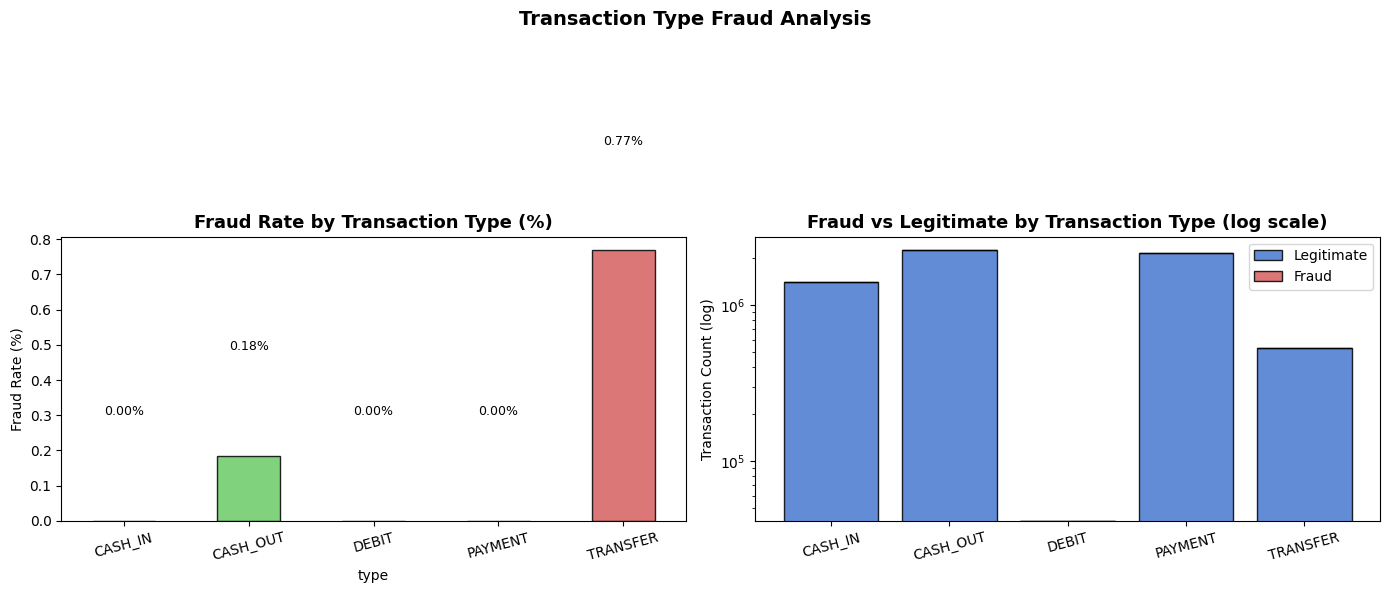


✅ Original df deleted. working_df is ready (split column already attached).


In [3]:
# Cell 3 — Load full dataset → stratified 70/15/15 split → subsample TRAIN ONLY
# Process: VAL and TEST are kept at the TRUE natural fraud rate (~0.13%).
#          Only the TRAIN portion is subsampled to ~50K (all train fraud kept).
#          This eliminates the artificial inflation of evaluation metrics.
try:
    df = pd.read_csv('/kaggle/input/datasets/amanalisiddiqui/fraud-detection-dataset/AIML Dataset.csv')
except:
    df = pd.read_csv('/kaggle/input/paysim1/paysim1.csv')

print(f"Original dataset : {df.shape}")
print(f"Fraud cases      : {df['isFraud'].sum()}")
print(f"Fraud %          : {df['isFraud'].mean()*100:.4f}%  ← REAL imbalance")

# ── Step 1: Stratified 70/15/15 split on the FULL dataset ──
df = df.reset_index(drop=True)
df['split'] = 'train'

train_idx, temp_idx = train_test_split(
    df.index, test_size=0.30,
    stratify=df['isFraud'], random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50,
    stratify=df.loc[temp_idx, 'isFraud'], random_state=42
)
df.loc[val_idx,  'split'] = 'val'
df.loc[test_idx, 'split'] = 'test'

print("\n--- Stratified Split on FULL Dataset (Natural Rate Preserved) ---")
for s in ['train', 'val', 'test']:
    sub = df[df['split'] == s]
    print(f"  {s.upper():<5}: {len(sub):>9,} rows | "
          f"Fraud: {sub['isFraud'].sum():>5,} "
          f"({sub['isFraud'].mean()*100:.4f}%)")

# ── Step 2: Subsample TRAIN ONLY to ~50K (keep all train fraud) ──
train_df = df[df['split'] == 'train']
fraud_tr = train_df[train_df['isFraud'] == 1]
legit_tr = train_df[train_df['isFraud'] == 0]
n_legit  = 50_000 - len(fraud_tr)
legit_tr_sample = legit_tr.sample(n=n_legit, random_state=42)
train_sub = (pd.concat([fraud_tr, legit_tr_sample])
               .sample(frac=1, random_state=42))

# ── Step 3: Build working_df = subsampled train + FULL val + FULL test ──
val_df  = df[df['split'] == 'val']
test_df = df[df['split'] == 'test']
working_df = pd.concat([train_sub, val_df, test_df]).reset_index(drop=True)

print("\n--- Working Dataset (TRAIN subsampled, VAL/TEST untouched) ---")
for s in ['train', 'val', 'test']:
    sub = working_df[working_df['split'] == s]
    print(f"  {s.upper():<5}: {len(sub):>9,} rows | "
          f"Fraud: {sub['isFraud'].sum():>5,} "
          f"({sub['isFraud'].mean()*100:.4f}%)")
print("\n  TRAIN  → enriched (~16% fraud) for learning signal, then SMOTE → 50/50")
print("  VAL    → NATURAL rate (~0.13%) for honest threshold tuning")
print("  TEST   → NATURAL rate (~0.13%) for honest deployment metrics")

# ── EDA: fraud by transaction type (computed on FULL df for accuracy) ──
type_fraud = df.groupby('type')['isFraud'].agg(['sum', 'count'])
type_fraud['fraud_rate'] = type_fraud['sum'] / type_fraud['count'] * 100
type_fraud.columns       = ['Fraud Count', 'Total Count', 'Fraud Rate (%)']
print(f"\n--- Transaction Type Fraud Analysis (Full Dataset) ---")
print(type_fraud)

fig, axes   = plt.subplots(1, 2, figsize=(14, 6))
type_colors = ['#4878CF', '#6ACC65', '#8A60B0', '#F5924E', '#D65F5F']
type_fraud['Fraud Rate (%)'].plot(kind='bar', ax=axes[0], color=type_colors,
                                   edgecolor='black', alpha=0.85)
axes[0].set_title('Fraud Rate by Transaction Type (%)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{bar.get_height():.2f}%', ha='center', fontsize=9)
legit_counts = type_fraud['Total Count'] - type_fraud['Fraud Count']
axes[1].bar(type_fraud.index, legit_counts, label='Legitimate',
            color='#4878CF', alpha=0.85, edgecolor='black')
axes[1].bar(type_fraud.index, type_fraud['Fraud Count'], bottom=legit_counts,
            label='Fraud', color='#D65F5F', alpha=0.85, edgecolor='black')
axes[1].set_title('Fraud vs Legitimate by Transaction Type (log scale)',
                  fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_ylabel('Transaction Count (log)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()
plt.suptitle("Transaction Type Fraud Analysis", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("type_fraud_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

del df
print("\n✅ Original df deleted. working_df is ready (split column already attached).")

In [4]:
# Cell 4 — Domain-Adaptive Feature Engineering (UPI / Indian Payment Systems)
# Process: Fully de-leaked feature set. Split column was created in Cell 3.
#
# REMOVED FEATURES (15 total):
#   ── Algebraic / quasi-label (removed earlier) ──
#   exact_balance_drain, orig_balance_error, dest_balance_error,
#   dest_balance_unchanged, cashout_full_drain, expected_newbal_orig,
#   expected_newbal_dest, balance_change_orig, balance_change_dest
#   ── PaySim fraud-signature features ──
#   zero_newbal_orig, orig_balance_ratio, amt_to_oldbal_orig, transfer_to_empty
#   ── Newly removed (this pass) ──
#   dest_balance_ratio    → encodes PaySim's "destination didn't update" pattern
#   amt_exceeds_balance   → impossible in real banking; only appears in PaySim quirks

paysim_df = working_df.copy()
del working_df

# 1. Transaction-type flags
paysim_df['UPI']         = np.where(paysim_df['type'] == 'PAYMENT', 1, 0)
paysim_df['NEFT']        = np.where((paysim_df['type'] == 'TRANSFER') &
                                     (paysim_df['amount'] <= 200000), 1, 0)
paysim_df['RTGS']        = np.where((paysim_df['type'] == 'TRANSFER') &
                                     (paysim_df['amount'] >  200000), 1, 0)
paysim_df['Credit']      = np.where(paysim_df['type'] == 'CASH_IN',  1, 0)
paysim_df['Debit']       = np.where(paysim_df['type'] == 'CASH_OUT', 1, 0)
paysim_df['DirectDebit'] = np.where(paysim_df['type'] == 'DEBIT',    1, 0)

# 2. UPI / regional rail-aware amount bands
amt = paysim_df['amount']
paysim_df['amt_upi_lite']     = (amt <= 500).astype(int)
paysim_df['amt_upi_micro']    = ((amt > 500)    & (amt <= 5000)).astype(int)
paysim_df['amt_upi_small']    = ((amt > 5000)   & (amt <= 25000)).astype(int)
paysim_df['amt_upi_medium']   = ((amt > 25000)  & (amt <= 100000)).astype(int)
paysim_df['amt_upi_max_band'] = ((amt > 100000) & (amt <= 200000)).astype(int)
paysim_df['amt_rtgs_band']    = ((amt > 200000) & (amt <= 1000000)).astype(int)
paysim_df['amt_high_value']   = (amt > 1000000).astype(int)
paysim_df['within_upi_cap']   = (amt <= 100000).astype(int)
paysim_df['rtgs_eligible']    = (amt >= 200000).astype(int)

# 3. Round-figure detectors
paysim_df['amt_round_100']   = (amt % 100   == 0).astype(int)
paysim_df['amt_round_1000']  = (amt % 1000  == 0).astype(int)
paysim_df['amt_round_10000'] = (amt % 10000 == 0).astype(int)

# 4. Logarithmic monetary features
paysim_df['log_amount']      = np.log1p(amt)
paysim_df['log_oldbal_orig'] = np.log1p(paysim_df['oldbalanceOrg'])
paysim_df['log_newbal_orig'] = np.log1p(paysim_df['newbalanceOrig'])
paysim_df['log_oldbal_dest'] = np.log1p(paysim_df['oldbalanceDest'])
paysim_df['log_newbal_dest'] = np.log1p(paysim_df['newbalanceDest'])

# 5. Ratio features (orig-side and dest_balance_ratio REMOVED)
eps = 1e-6
paysim_df['amt_to_oldbal_dest'] = amt / (paysim_df['oldbalanceDest'] + eps)

# 6. Anomaly indicators (zero_newbal_orig + amt_exceeds_balance REMOVED)
paysim_df['zero_oldbal_orig'] = (paysim_df['oldbalanceOrg']  == 0).astype(int)
paysim_df['zero_oldbal_dest'] = (paysim_df['oldbalanceDest'] == 0).astype(int)
paysim_df['zero_newbal_dest'] = (paysim_df['newbalanceDest'] == 0).astype(int)

# 7. Temporal proxies
paysim_df['step_hour']        = paysim_df['step'] % 24
paysim_df['step_day']         = paysim_df['step'] // 24
paysim_df['is_night_hour']    = ((paysim_df['step_hour'] >= 0) &
                                  (paysim_df['step_hour']  < 6)).astype(int)
paysim_df['is_business_hour'] = ((paysim_df['step_hour'] >= 9) &
                                  (paysim_df['step_hour'] <= 18)).astype(int)

# 8. Cross-feature interactions (transfer_to_empty REMOVED)
paysim_df['upi_high_amount'] = (paysim_df['UPI'] *
                                 (amt > 50000).astype(int)).astype(int)

feature_names = [
    # Original transactional features
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    # Transaction-type features
    'UPI', 'NEFT', 'RTGS', 'Credit', 'Debit', 'DirectDebit',
    # Amount-band features
    'amt_upi_lite', 'amt_upi_micro', 'amt_upi_small',
    'amt_upi_medium', 'amt_upi_max_band', 'amt_rtgs_band',
    'amt_high_value', 'within_upi_cap', 'rtgs_eligible',
    # Round-figure indicators
    'amt_round_100', 'amt_round_1000', 'amt_round_10000',
    # Log features
    'log_amount', 'log_oldbal_orig', 'log_newbal_orig',
    'log_oldbal_dest', 'log_newbal_dest',
    # Ratio features (dest-side amount-to-balance only)
    'amt_to_oldbal_dest',
    # Risk / anomaly indicators
    'zero_oldbal_orig', 'zero_oldbal_dest', 'zero_newbal_dest',
    # Temporal features
    'step_hour', 'step_day', 'is_night_hour', 'is_business_hour',
    # Interaction features
    'upi_high_amount',
]

# Sanity checks
overlap = ((paysim_df['NEFT'] == 1) & (paysim_df['RTGS'] == 1)).sum()
print(f"NEFT + RTGS overlap : {overlap} (must be 0 ✅)")
print(f"Total features      : {len(feature_names)}  (was 43; removed 2 leaky)")
print("\nNewly removed (this pass):")
print("   • dest_balance_ratio   (PaySim destination-non-update signature)")
print("   • amt_exceeds_balance  (impossible in real banking)")

NEFT + RTGS overlap : 0 (must be 0 ✅)
Total features      : 38  (was 43; removed 2 leaky)

Newly removed (this pass):
   • dest_balance_ratio   (PaySim destination-non-update signature)
   • amt_exceeds_balance  (impossible in real banking)


In [5]:
# Cell 5 — Assign Train / Val / Test from Cell 3's stratified splits
X_train = paysim_df.loc[paysim_df['split'] == 'train', feature_names].reset_index(drop=True)
y_train = paysim_df.loc[paysim_df['split'] == 'train', 'isFraud'].reset_index(drop=True)
X_val   = paysim_df.loc[paysim_df['split'] == 'val',   feature_names].reset_index(drop=True)
y_val   = paysim_df.loc[paysim_df['split'] == 'val',   'isFraud'].reset_index(drop=True)
X_test  = paysim_df.loc[paysim_df['split'] == 'test',  feature_names].reset_index(drop=True)
y_test  = paysim_df.loc[paysim_df['split'] == 'test',  'isFraud'].reset_index(drop=True)

print(f"Training set   : {X_train.shape}  Fraud: {y_train.sum()} "
      f"({y_train.mean()*100:.2f}%)  ← subsampled for signal; SMOTE next")
print(f"Validation set : {X_val.shape}    Fraud: {y_val.sum()} "
      f"({y_val.mean()*100:.4f}%)  ← TRUE natural rate")
print(f"Test set       : {X_test.shape}   Fraud: {y_test.sum()} "
      f"({y_test.mean()*100:.4f}%)  ← TRUE natural rate")
print("\n✅ Honest evaluation: VAL and TEST untouched at real-world imbalance.")

Training set   : (50000, 38)  Fraud: 5749 (11.50%)  ← subsampled for signal; SMOTE next
Validation set : (954393, 38)    Fraud: 1232 (0.1291%)  ← TRUE natural rate
Test set       : (954393, 38)   Fraud: 1232 (0.1291%)  ← TRUE natural rate

✅ Honest evaluation: VAL and TEST untouched at real-world imbalance.


In [6]:
# Cell 6 — Scaler + SMOTE + Evaluation Function
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

smote                    = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE : {X_train_scaled.shape}  Fraud: {y_train.sum()}")
print(f"After  SMOTE : {X_train_res.shape}      Fraud: {y_train_res.sum()}")

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    metrics = {
        'Accuracy'  : round(accuracy_score(y_te, y_pred)           * 100, 2),
        'Precision' : round(precision_score(y_te, y_pred)          * 100, 2),
        'Recall'    : round(recall_score(y_te, y_pred)             * 100, 2),
        'F1 Score'  : round(f1_score(y_te, y_pred)                 * 100, 2),
        'AUC-ROC'   : round(roc_auc_score(y_te, y_prob)            * 100, 2),
        'AUC-PR'    : round(average_precision_score(y_te, y_prob)  * 100, 2),
        'MCC'       : round(matthews_corrcoef(y_te, y_pred)        * 100, 2),
    }
    print(f"  {name:<28} → {metrics}")
    return metrics
print("\n✅ Scaler, SMOTE and evaluate_model ready")

Before SMOTE : (50000, 38)  Fraud: 5749
After  SMOTE : (88502, 38)      Fraud: 44251

✅ Scaler, SMOTE and evaluate_model ready


Running 5-Fold Cross Validation on 5 base models...

(SMOTE applied inside each fold — no data leakage)

  ▶ Logistic Regression...
    Accuracy : 98.58% ± 0.08%
    F1 Score : 93.95% ± 0.37%
    AUC-ROC  : 99.69% ± 0.03%
    AUC-PR   : 98.79% ± 0.14%
    MCC      : 93.17% ± 0.42%

  ▶ Decision Tree...
    Accuracy : 98.50% ± 0.31%
    F1 Score : 93.79% ± 1.17%
    AUC-ROC  : 99.40% ± 0.06%
    AUC-PR   : 97.31% ± 0.49%
    MCC      : 93.07% ± 1.26%

  ▶ Naive Bayes...
    Accuracy : 79.98% ± 0.08%
    F1 Score : 53.15% ± 0.05%
    AUC-ROC  : 95.07% ± 0.21%
    AUC-PR   : 59.82% ± 0.95%
    MCC      : 52.52% ± 0.15%

  ▶ Random Forest...
    Accuracy : 99.43% ± 0.07%
    F1 Score : 97.56% ± 0.30%
    AUC-ROC  : 99.90% ± 0.02%
    AUC-PR   : 99.67% ± 0.05%
    MCC      : 97.25% ± 0.33%

  ▶ XGBoost...
    Accuracy : 99.63% ± 0.04%
    F1 Score : 98.38% ± 0.18%
    AUC-ROC  : 99.92% ± 0.03%
    AUC-PR   : 99.78% ± 0.04%
    MCC      : 98.18% ± 0.20%

Model                        Accuracy

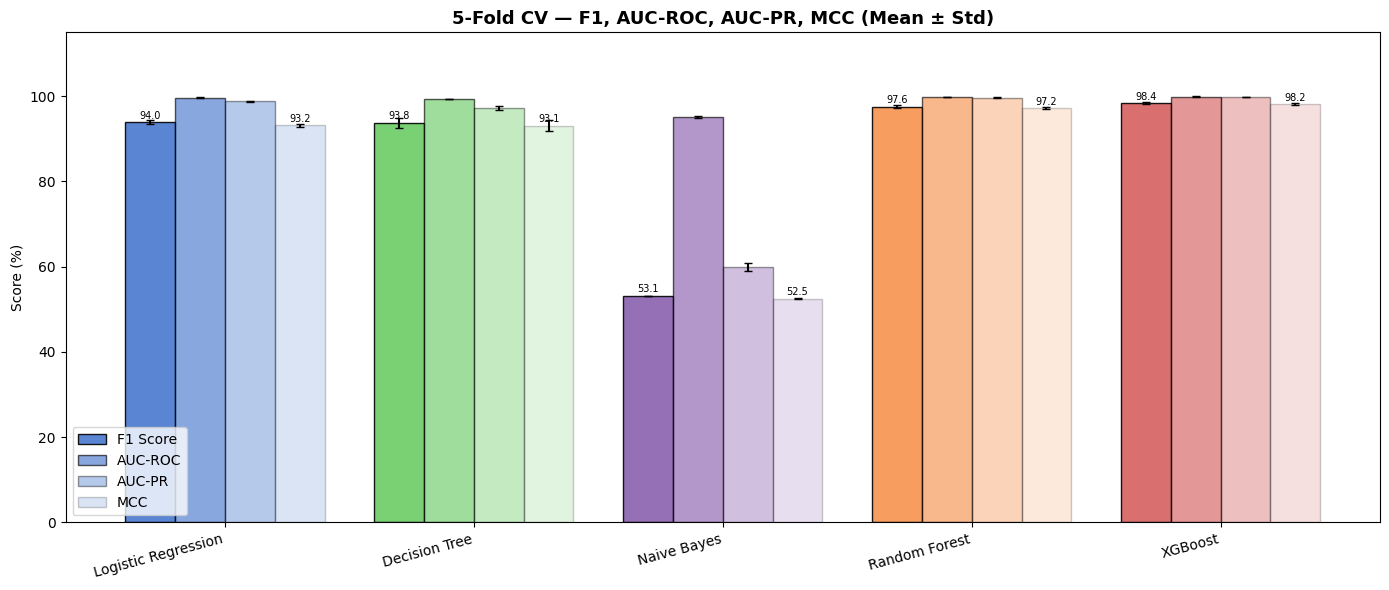

✅ 5-Fold CV complete — proceed to model selection


In [7]:
# Cell 7 — 5-Fold Cross Validation on All 5 Base Models
# Process: CV with SMOTE inside each fold on X_train only → used to select best 2 models
print("Running 5-Fold Cross Validation on 5 base models...\n")
print("(SMOTE applied inside each fold — no data leakage)\n")
X_cv = X_train.copy()
y_cv = y_train.copy()
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc',
           'average_precision', 'matthews_corrcoef']
cv_model_defs = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(tree_method='hist', eval_metric='auc',
                                           random_state=42),
}
cv_results = {}
for name, model in cv_model_defs.items():
    print(f"  ▶ {name}...")
    pipe = ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    scores = cross_validate(pipe, X_cv, y_cv, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy'  : round(scores['test_accuracy'].mean()            * 100, 2),
        'Precision' : round(scores['test_precision'].mean()           * 100, 2),
        'Recall'    : round(scores['test_recall'].mean()              * 100, 2),
        'F1 Score'  : round(scores['test_f1'].mean()                  * 100, 2),
        'AUC-ROC'   : round(scores['test_roc_auc'].mean()             * 100, 2),
        'AUC-PR'    : round(scores['test_average_precision'].mean()   * 100, 2),
        'MCC'       : round(scores['test_matthews_corrcoef'].mean()   * 100, 2),
        'Acc_std'   : round(scores['test_accuracy'].std()             * 100, 2),
        'Pre_std'   : round(scores['test_precision'].std()            * 100, 2),
        'Rec_std'   : round(scores['test_recall'].std()               * 100, 2),
        'F1_std'    : round(scores['test_f1'].std()                   * 100, 2),
        'AUC_std'   : round(scores['test_roc_auc'].std()              * 100, 2),
        'PR_std'    : round(scores['test_average_precision'].std()    * 100, 2),
        'MCC_std'   : round(scores['test_matthews_corrcoef'].std()    * 100, 2),
    }
    r = cv_results[name]
    print(f"    Accuracy : {r['Accuracy']:.2f}% ± {r['Acc_std']:.2f}%")
    print(f"    F1 Score : {r['F1 Score']:.2f}% ± {r['F1_std']:.2f}%")
    print(f"    AUC-ROC  : {r['AUC-ROC']:.2f}% ± {r['AUC_std']:.2f}%")
    print(f"    AUC-PR   : {r['AUC-PR']:.2f}% ± {r['PR_std']:.2f}%")
    print(f"    MCC      : {r['MCC']:.2f}% ± {r['MCC_std']:.2f}%\n")

print("=" * 120)
print(f"{'Model':<22} {'Accuracy':>14} {'F1 Score':>14} "
      f"{'AUC-ROC':>14} {'AUC-PR':>14} {'MCC':>14}")
print("=" * 120)
for name, r in cv_results.items():
    print(f"{name:<22} "
          f"{r['Accuracy']:>6.2f}±{r['Acc_std']:<6.2f}"
          f"{r['F1 Score']:>6.2f}±{r['F1_std']:<6.2f}"
          f"{r['AUC-ROC']:>6.2f}±{r['AUC_std']:<6.2f}"
          f"{r['AUC-PR']:>6.2f}±{r['PR_std']:<6.2f}"
          f"{r['MCC']:>6.2f}±{r['MCC_std']:<6.2f}")
print("=" * 120)

names     = list(cv_results.keys())
f1s       = [cv_results[n]['F1 Score'] for n in names]
aucs      = [cv_results[n]['AUC-ROC']  for n in names]
prs       = [cv_results[n]['AUC-PR']   for n in names]
mccs      = [cv_results[n]['MCC']      for n in names]
f1_err    = [cv_results[n]['F1_std']   for n in names]
auc_err   = [cv_results[n]['AUC_std']  for n in names]
pr_err    = [cv_results[n]['PR_std']   for n in names]
mcc_err   = [cv_results[n]['MCC_std']  for n in names]
cv_colors = ['#4878CF', '#6ACC65', '#8A60B0', '#F5924E', '#D65F5F']
x, w = np.arange(len(names)), 0.2
fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - 1.5*w, f1s,  w, yerr=f1_err,  capsize=3,
               label='F1 Score', color=cv_colors, alpha=0.90, edgecolor='black')
bars2 = ax.bar(x - 0.5*w, aucs, w, yerr=auc_err, capsize=3,
               label='AUC-ROC',  color=cv_colors, alpha=0.65, edgecolor='black')
bars3 = ax.bar(x + 0.5*w, prs,  w, yerr=pr_err,  capsize=3,
               label='AUC-PR',   color=cv_colors, alpha=0.40, edgecolor='black')
bars4 = ax.bar(x + 1.5*w, mccs, w, yerr=mcc_err, capsize=3,
               label='MCC',      color=cv_colors, alpha=0.20, edgecolor='black')
for bar, v in zip(bars1, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{v:.1f}', ha='center', fontsize=7)
for bar, v in zip(bars4, mccs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{v:.1f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 115); ax.set_ylabel("Score (%)")
ax.set_title("5-Fold CV — F1, AUC-ROC, AUC-PR, MCC (Mean ± Std)",
             fontsize=13, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig("cv_base_models.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 5-Fold CV complete — proceed to model selection")

In [8]:
# Cell 8 — Dynamic Best 2 Model Selection
# Process: Rank all 5 models by CV F1 Score; select top 2 for hypertuning and ensemble
cv_df = (pd.DataFrame(
            {k: {m: cv_results[k][m]
                 for m in ['Accuracy', 'Precision', 'Recall',
                           'F1 Score', 'AUC-ROC', 'AUC-PR', 'MCC']}
             for k in cv_results})
         .T
         .sort_values('F1 Score', ascending=False))
print("CV Rankings (sorted by F1 Score):\n")
print(cv_df.round(2).to_string())
best_2_names = list(cv_df.head(2).index)
print(f"\n✅ Best 2 models selected for hypertuning + ensemble:")
for i, name in enumerate(best_2_names):
    r = cv_results[name]
    print(f"   {i+1}. {name:<22} "
          f"F1={r['F1 Score']}%  AUC-ROC={r['AUC-ROC']}%  "
          f"AUC-PR={r['AUC-PR']}%  MCC={r['MCC']}%")
print(f"\nMethod    : Stacking with Logistic Regression meta-learner")
print(f"Rationale : Top 2 CV performers → diverse errors → stronger ensemble")

CV Rankings (sorted by F1 Score):

                     Accuracy  Precision  Recall  F1 Score  AUC-ROC  AUC-PR    MCC
XGBoost                 99.63      97.72   99.06     98.38    99.92   99.78  98.18
Random Forest           99.43      96.46   98.70     97.56    99.90   99.67  97.25
Logistic Regression     98.58      92.22   95.76     93.95    99.69   98.79  93.17
Decision Tree           98.50      89.89   98.10     93.79    99.40   97.31  93.07
Naive Bayes             79.98      36.36   98.77     53.15    95.07   59.82  52.52

✅ Best 2 models selected for hypertuning + ensemble:
   1. XGBoost                F1=98.38%  AUC-ROC=99.92%  AUC-PR=99.78%  MCC=98.18%
   2. Random Forest          F1=97.56%  AUC-ROC=99.9%  AUC-PR=99.67%  MCC=97.25%

Method    : Stacking with Logistic Regression meta-learner
Rationale : Top 2 CV performers → diverse errors → stronger ensemble


In [9]:
# Cell 9 — Hyperparameter Tuning of Both Best Models (5-Fold CV, Pipeline-Based)
# Process: RandomizedSearchCV with ImbPipeline so SMOTE is inside each fold (no leakage)
all_param_grids = {
    'XGBoost': {
        'model__n_estimators'     : [100, 200, 300],
        'model__max_depth'        : [3, 5, 7],
        'model__learning_rate'    : [0.01, 0.05, 0.1],
        'model__subsample'        : [0.7, 0.8, 1.0],
        'model__colsample_bytree' : [0.7, 0.8, 1.0],
        'model__min_child_weight' : [1, 3, 5],
        'model__gamma'            : [0, 0.1, 0.2],
    },
    'Random Forest': {
        'model__n_estimators'      : [100, 200, 300],
        'model__max_depth'         : [10, 20, None],
        'model__min_samples_split' : [2, 5, 10],
        'model__min_samples_leaf'  : [1, 2, 4],
        'model__max_features'      : ['sqrt', 'log2'],
    },
    'Decision Tree': {
        'model__max_depth'         : [5, 10, 15, 20, None],
        'model__min_samples_split' : [2, 5, 10],
        'model__min_samples_leaf'  : [1, 2, 4],
        'model__criterion'         : ['gini', 'entropy'],
    },
    'Logistic Regression': {
        'model__C'       : [0.01, 0.1, 1, 10, 100],
        'model__solver'  : ['lbfgs', 'liblinear'],
        'model__penalty' : ['l2'],
    },
    'Naive Bayes': {},
}
base_model_map = {
    'XGBoost'             : XGBClassifier(tree_method='hist', eval_metric='auc',
                                           random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes'         : GaussianNB(),
}
best_params     = {}
best_estimators = {}
for name in best_2_names:
    print(f"\n{'='*58}")
    print(f"  Tuning : {name}")
    print(f"{'='*58}")
    grid = all_param_grids.get(name, {})
    if not grid:
        print(f"  ℹ️  No hyperparameters to tune. Using default.")
        best_estimators[name] = clone(base_model_map[name])
        best_params[name]     = {}
        continue
    pipe = ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  clone(base_model_map[name]))
    ])
    search = RandomizedSearchCV(
        pipe,
        param_distributions = grid,
        n_iter       = 30,
        scoring      = 'f1',
        cv           = 5,
        random_state = 42,
        n_jobs       = -1,
        verbose      = 1
    )
    search.fit(X_train, y_train)
    best_params[name] = {k.replace('model__', ''): v
                         for k, v in search.best_params_.items()}
    tuned_model = clone(base_model_map[name]).set_params(**best_params[name])
    tuned_model.fit(X_train_res, y_train_res)
    best_estimators[name] = tuned_model
    pred = tuned_model.predict(X_test_scaled)
    prob = tuned_model.predict_proba(X_test_scaled)[:, 1]
    print(f"\n  Best Params  : {best_params[name]}")
    print(f"  Tuned F1     : {round(f1_score(y_test, pred)*100, 2)}%")
    print(f"  Tuned AUC    : {round(roc_auc_score(y_test, prob)*100, 2)}%")
    print(f"  Tuned Recall : {round(recall_score(y_test, pred)*100, 2)}%")
print(f"\n✅ Hypertuning complete for: {best_2_names}")


  Tuning : XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Best Params  : {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}
  Tuned F1     : 40.54%
  Tuned AUC    : 99.97%
  Tuned Recall : 99.03%

  Tuning : Random Forest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Best Params  : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
  Tuned F1     : 35.23%
  Tuned AUC    : 99.92%
  Tuned Recall : 99.11%

✅ Hypertuning complete for: ['XGBoost', 'Random Forest']


In [10]:
# Cell 10 — Train All 5 Models
# Process: Train all 5 models — best 2 use tuned estimators from Cell 9, rest use defaults
results        = {}
trained_models = {}
print("Training all 5 models...\n")
model_configs = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(tree_method='hist', eval_metric='auc',
                                           random_state=42),
}
for model_name, default_model in model_configs.items():
    model        = best_estimators.get(model_name, default_model)
    display_name = f"{model_name} (tuned ✅)" if model_name in best_2_names else model_name
    results[model_name]        = evaluate_model(
        display_name, model, X_train_res, y_train_res, X_test_scaled, y_test)
    trained_models[model_name] = model
print("\n✅ All 5 models trained")

Training all 5 models...

  Logistic Regression          → {'Accuracy': 97.74, 'Precision': 5.37, 'Recall': 99.27, 'F1 Score': 10.18, 'AUC-ROC': np.float64(99.79), 'AUC-PR': np.float64(74.18), 'MCC': np.float64(22.81)}
  Decision Tree                → {'Accuracy': 99.15, 'Precision': 13.07, 'Recall': 98.54, 'F1 Score': 23.08, 'AUC-ROC': np.float64(99.62), 'AUC-PR': np.float64(38.12), 'MCC': np.float64(35.73)}
  Naive Bayes                  → {'Accuracy': 77.43, 'Precision': 0.56, 'Recall': 98.38, 'F1 Score': 1.11, 'AUC-ROC': np.float64(95.92), 'AUC-PR': np.float64(2.08), 'MCC': np.float64(6.5)}
  Random Forest (tuned ✅)      → {'Accuracy': 99.53, 'Precision': 21.42, 'Recall': 99.11, 'F1 Score': 35.23, 'AUC-ROC': np.float64(99.92), 'AUC-PR': np.float64(93.22), 'MCC': np.float64(45.97)}
  XGBoost (tuned ✅)            → {'Accuracy': 99.62, 'Precision': 25.49, 'Recall': 99.03, 'F1 Score': 40.54, 'AUC-ROC': np.float64(99.97), 'AUC-PR': np.float64(94.72), 'MCC': np.float64(50.14)}

✅ All 5 m

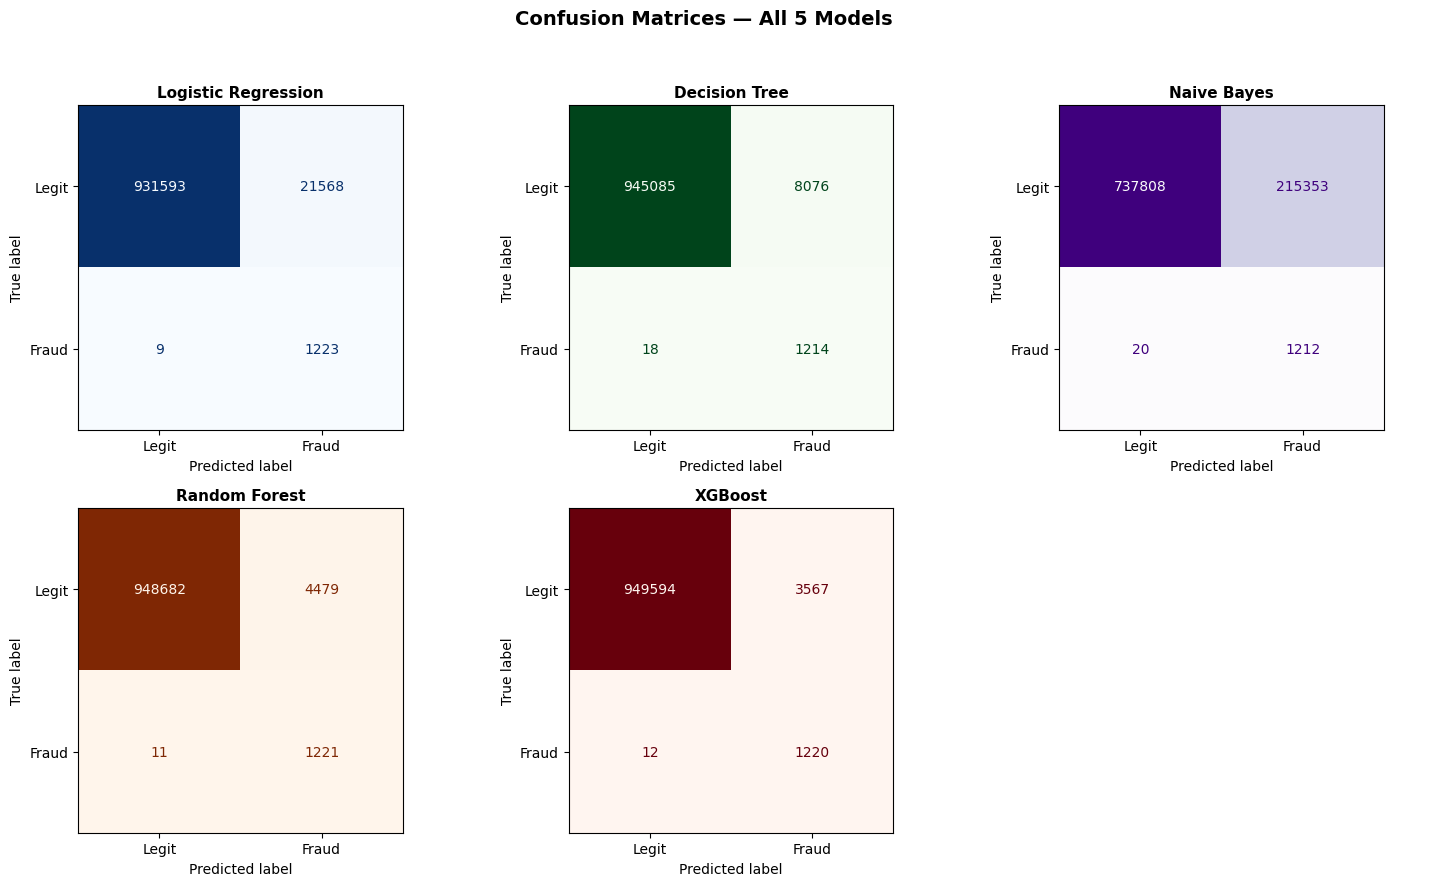

In [11]:
# Cell 11 — Confusion Matrices (All 5 Models)
# Process: Plot 2×3 confusion matrix grid for all 5 trained models
model_list = [
    ('Logistic Regression', trained_models['Logistic Regression'], 'Blues'),
    ('Decision Tree',       trained_models['Decision Tree'],       'Greens'),
    ('Naive Bayes',         trained_models['Naive Bayes'],         'Purples'),
    ('Random Forest',       trained_models['Random Forest'],       'Oranges'),
    ('XGBoost',             trained_models['XGBoost'],             'Reds'),
]
colors = ['#4878CF', '#6ACC65', '#8A60B0', '#F5924E', '#D65F5F']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, model, cmap) in enumerate(model_list):
    y_pred = model.predict(X_test_scaled)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[idx], colorbar=False, cmap=cmap)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
axes[5].axis('off')
plt.suptitle("Confusion Matrices — All 5 Models", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

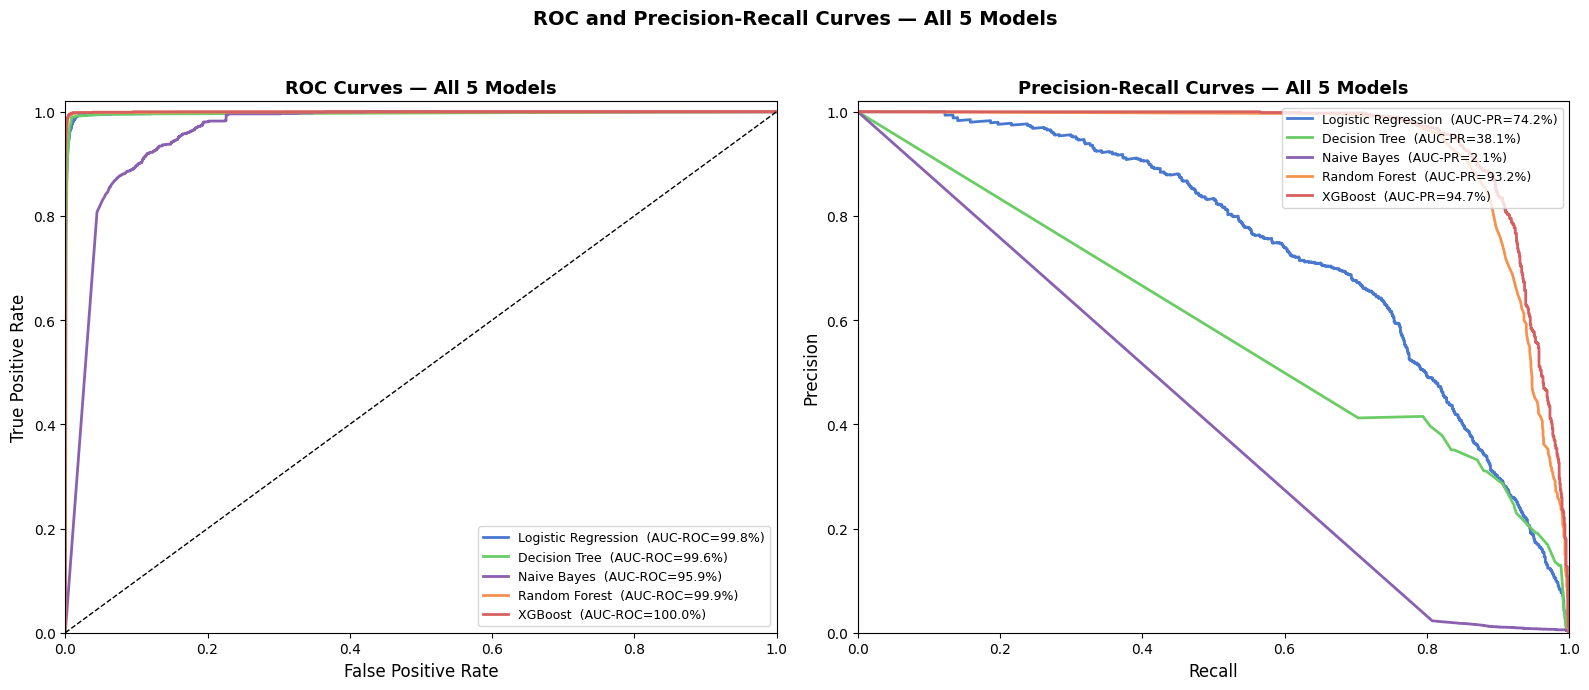

In [12]:
# Cell 12 — ROC Curves + Precision-Recall Curves (All 5 Models)
# Process: Plot ROC and PR curves side by side for all 5 models
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for (name, model, _), color in zip(model_list, colors):
    y_prob      = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name}  (AUC-ROC={results[name]["AUC-ROC"]:.1f}%)')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate',  fontsize=12)
axes[0].set_title('ROC Curves — All 5 Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

for (name, model, _), color in zip(model_list, colors):
    y_prob       = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name}  (AUC-PR={results[name]["AUC-PR"]:.1f}%)')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('Recall',    fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves — All 5 Models',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
plt.suptitle("ROC and Precision-Recall Curves — All 5 Models",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("roc_pr_curves_5models.png", dpi=150, bbox_inches='tight')
plt.show()

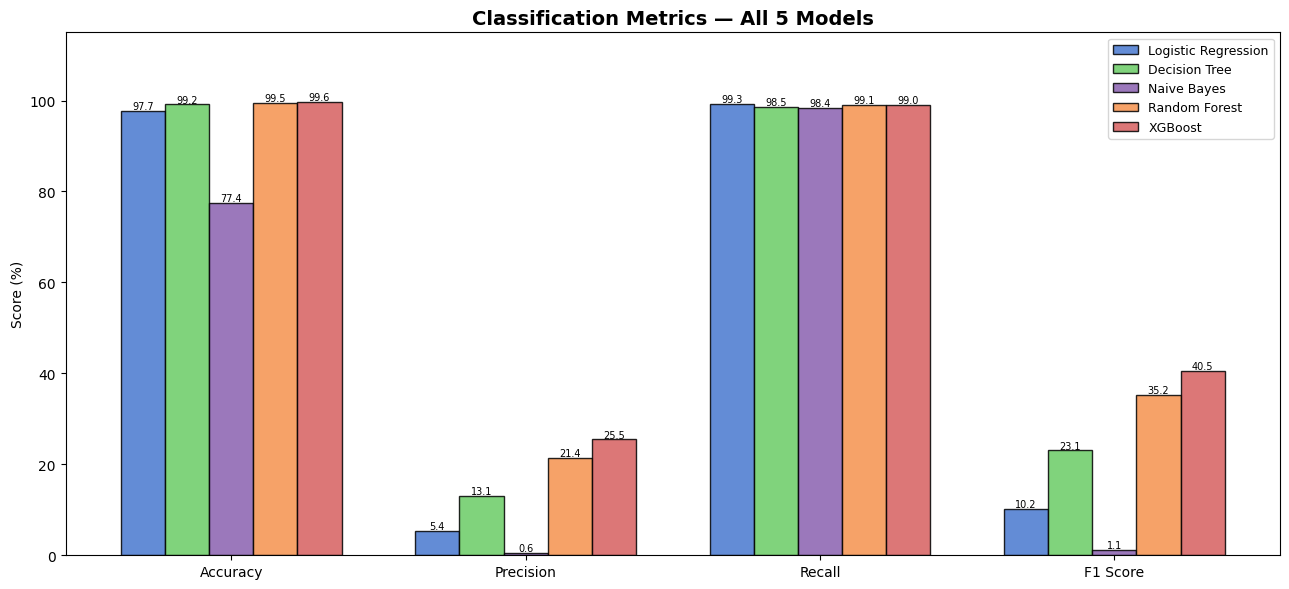

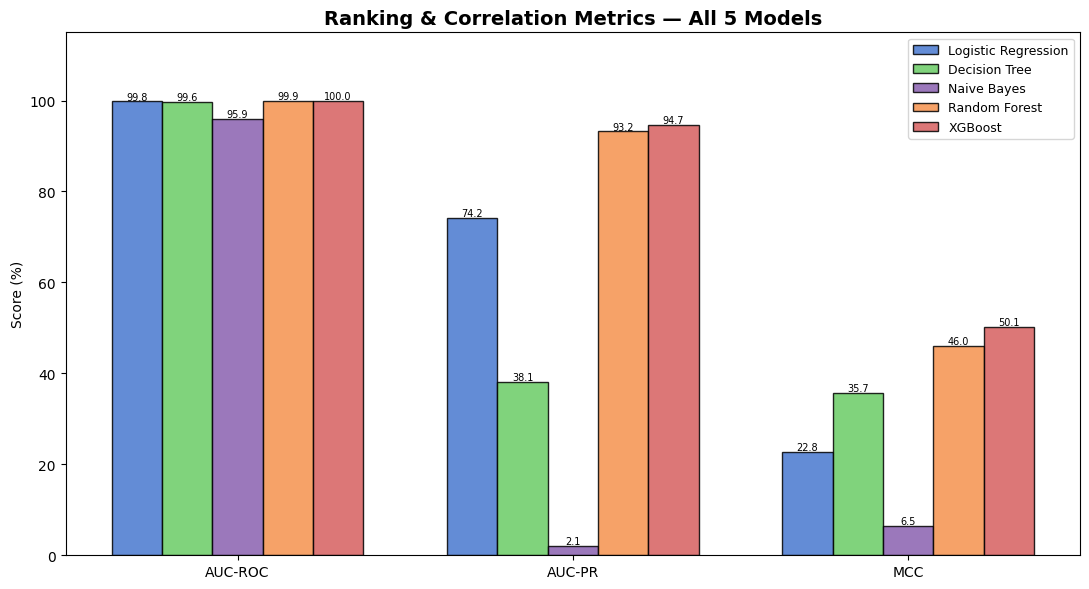

In [13]:
# Cell 13 — Metrics Comparison Bar Charts (All 5 Models)
# Process: Two grouped bar charts — classification metrics and ranking metrics
metrics_clf = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x     = np.arange(len(metrics_clf))
width = 0.15
fig, ax = plt.subplots(figsize=(13, 6))
for i, ((name, _, _), color) in enumerate(zip(model_list, colors)):
    vals = [results[name][m] for m in metrics_clf]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', fontsize=7)
ax.set_xticks(x + width * 2); ax.set_xticklabels(metrics_clf)
ax.set_ylim(0, 115); ax.set_ylabel('Score (%)')
ax.set_title('Classification Metrics — All 5 Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig("metrics_clf_5models.png", dpi=150, bbox_inches='tight')
plt.show()

metrics_rank = ['AUC-ROC', 'AUC-PR', 'MCC']
x     = np.arange(len(metrics_rank))
width = 0.15
fig, ax = plt.subplots(figsize=(11, 6))
for i, ((name, _, _), color) in enumerate(zip(model_list, colors)):
    vals = [results[name][m] for m in metrics_rank]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', fontsize=7)
ax.set_xticks(x + width * 2); ax.set_xticklabels(metrics_rank)
ax.set_ylim(0, 115); ax.set_ylabel('Score (%)')
ax.set_title('Ranking & Correlation Metrics — All 5 Models',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig("metrics_rank_5models.png", dpi=150, bbox_inches='tight')
plt.show()

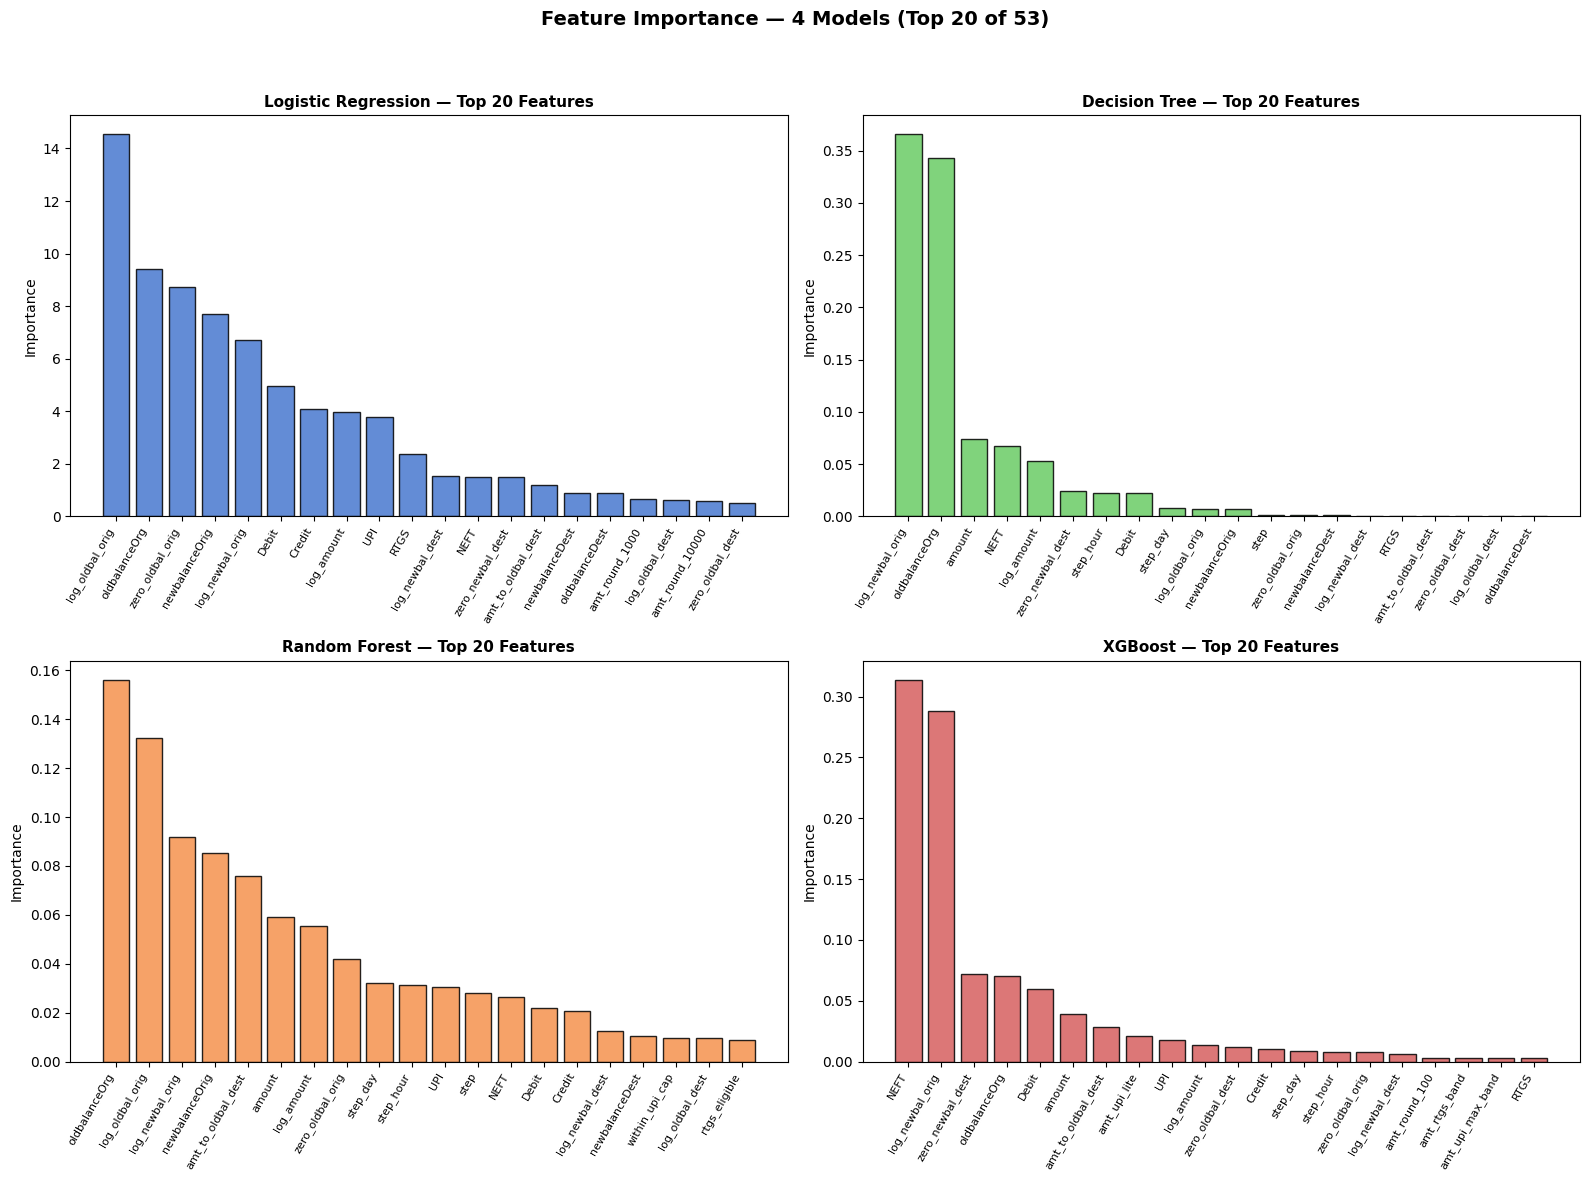

In [14]:
# Cell 14 — Feature Importance (4 Models)
# Process: Bar charts of feature importance for LR (coef), DT, RF, XGBoost
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
fi_models = {
    'Logistic Regression' : abs(trained_models['Logistic Regression'].coef_[0]),
    'Decision Tree'       : trained_models['Decision Tree'].feature_importances_,
    'Random Forest'       : trained_models['Random Forest'].feature_importances_,
    'XGBoost'             : trained_models['XGBoost'].feature_importances_,
}
fi_colors = ['#4878CF', '#6ACC65', '#F5924E', '#D65F5F']
for idx, ((name, importances), color) in enumerate(zip(fi_models.items(), fi_colors)):
    sorted_idx = np.argsort(importances)[::-1][:20]   # top-20 (53 features → too crowded)
    axes[idx].bar(range(len(sorted_idx)),
                  importances[sorted_idx],
                  color=color, alpha=0.85, edgecolor='black')
    axes[idx].set_xticks(range(len(sorted_idx)))
    axes[idx].set_xticklabels(
        [feature_names[i] for i in sorted_idx],
        rotation=60, ha='right', fontsize=8)
    axes[idx].set_title(f'{name} — Top 20 Features',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Importance')
plt.suptitle("Feature Importance — 4 Models (Top 20 of 53)", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Cell 15 — Train Ensemble (Stacking — Best 2 Tuned Models)
# Process: Stack the 2 tuned best models with LR as meta-learner using 5-fold stacking CV
from sklearn.ensemble import StackingClassifier
from sklearn.base import clone
estimators = [(name, clone(trained_models[name])) for name in best_2_names]
print(f"Stacking : {best_2_names[0]} + {best_2_names[1]} → LR meta-learner\n")
ensemble = StackingClassifier(
    estimators      = estimators,
    final_estimator = LogisticRegression(max_iter=1000, random_state=42),
    cv              = 5,
    stack_method    = 'predict_proba',
    passthrough     = False,
    n_jobs          = -1
)
ensemble.fit(X_train_res, y_train_res)
ens_pred = ensemble.predict(X_test_scaled)
ens_prob = ensemble.predict_proba(X_test_scaled)[:, 1]
results['Ensemble (Best 2)'] = {
    'Accuracy'  : round(accuracy_score(y_test, ens_pred)           * 100, 2),
    'Precision' : round(precision_score(y_test, ens_pred)          * 100, 2),
    'Recall'    : round(recall_score(y_test, ens_pred)             * 100, 2),
    'F1 Score'  : round(f1_score(y_test, ens_pred)                 * 100, 2),
    'AUC-ROC'   : round(roc_auc_score(y_test, ens_prob)            * 100, 2),
    'AUC-PR'    : round(average_precision_score(y_test, ens_prob)  * 100, 2),
    'MCC'       : round(matthews_corrcoef(y_test, ens_pred)        * 100, 2),
}
print(f"✅ Stacking Ensemble trained  ({' + '.join(best_2_names)})")
print(f"   Results : {results['Ensemble (Best 2)']}")

Stacking : XGBoost + Random Forest → LR meta-learner

✅ Stacking Ensemble trained  (XGBoost + Random Forest)
   Results : {'Accuracy': 99.68, 'Precision': 28.51, 'Recall': 98.94, 'F1 Score': 44.27, 'AUC-ROC': np.float64(99.97), 'AUC-PR': np.float64(94.81), 'MCC': np.float64(53.03)}


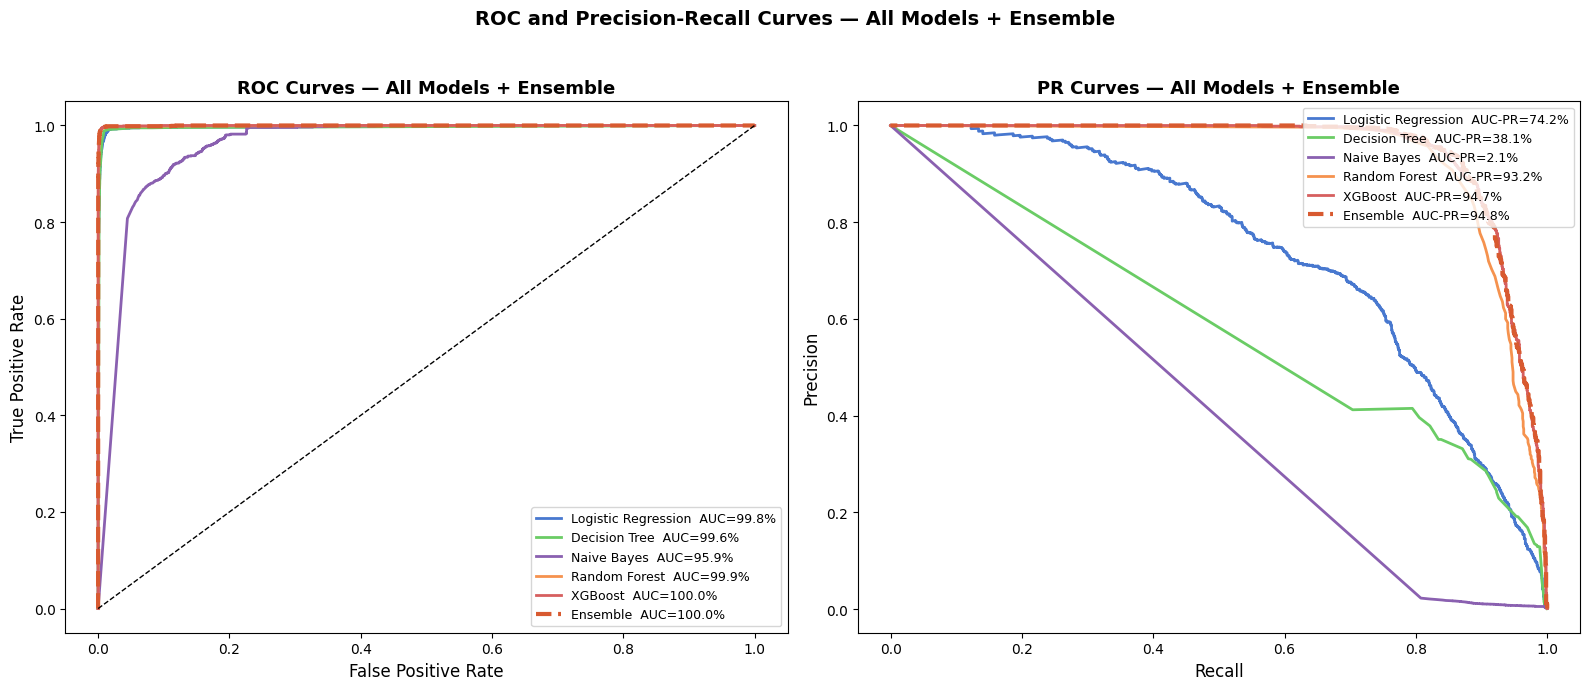

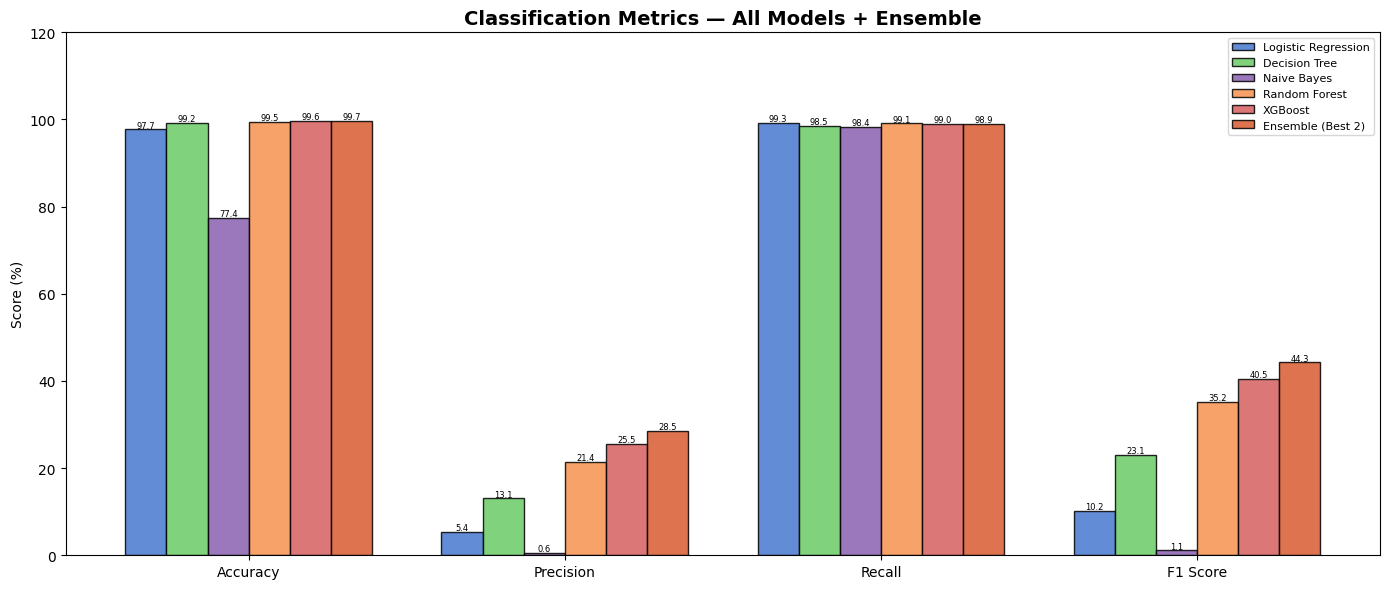

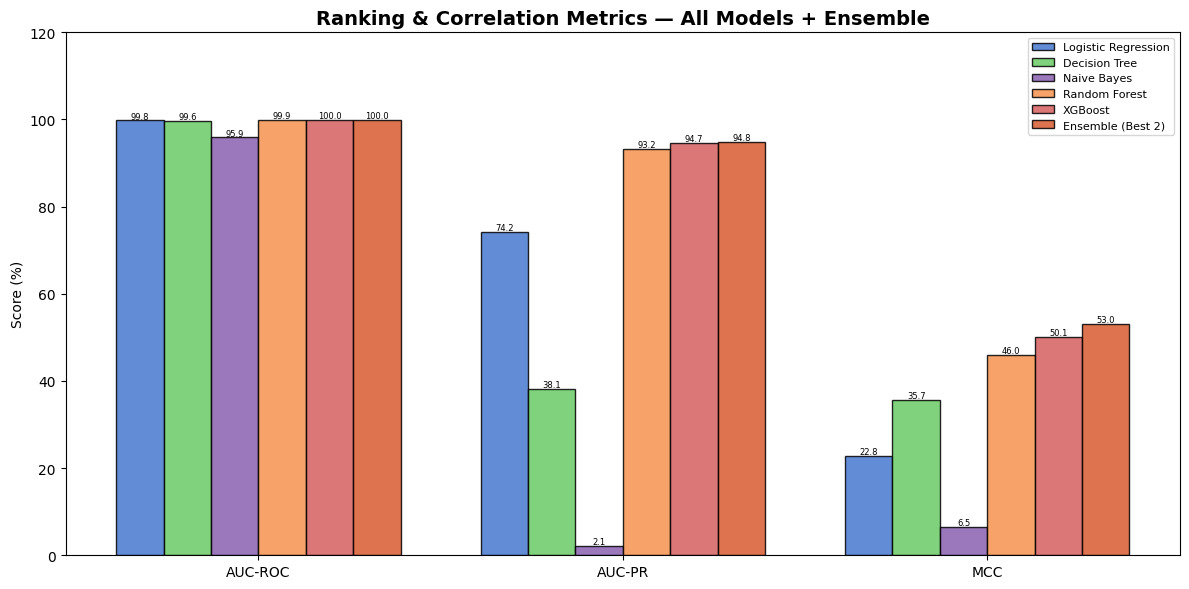

In [16]:
# Cell 16 — Combined Charts (All 5 Models + Ensemble)
# Process: Combined ROC+PR curves and two metrics bar charts including ensemble
model_list_full = model_list + [('Ensemble (Best 2)', ensemble, 'Greys')]
colors_full     = colors     + ['#D85A30']
all_names_full  = [m[0] for m in model_list_full]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for (name, model, _), color in zip(model_list, colors):
    y_prob      = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name}  AUC={results[name]["AUC-ROC"]:.1f}%')
y_prob_ens       = ensemble.predict_proba(X_test_scaled)[:, 1]
fpr_e, tpr_e, _  = roc_curve(y_test, y_prob_ens)
axes[0].plot(fpr_e, tpr_e, color='#D85A30', lw=3, linestyle='--',
             label=f'Ensemble  AUC={results["Ensemble (Best 2)"]["AUC-ROC"]:.1f}%')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate',  fontsize=12)
axes[0].set_title('ROC Curves — All Models + Ensemble', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

for (name, model, _), color in zip(model_list, colors):
    y_prob       = model.predict_proba(X_test_scaled)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{name}  AUC-PR={results[name]["AUC-PR"]:.1f}%')
prec_e, rec_e, _ = precision_recall_curve(y_test, y_prob_ens)
axes[1].plot(rec_e, prec_e, color='#D85A30', lw=3, linestyle='--',
             label=f'Ensemble  AUC-PR={results["Ensemble (Best 2)"]["AUC-PR"]:.1f}%')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('PR Curves — All Models + Ensemble', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
plt.suptitle("ROC and Precision-Recall Curves — All Models + Ensemble",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("combined_roc_pr.png", dpi=150, bbox_inches='tight')
plt.show()

metrics_clf = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x     = np.arange(len(metrics_clf))
width = 0.13
fig, ax = plt.subplots(figsize=(14, 6))
for i, ((name, _, _), color) in enumerate(zip(model_list_full, colors_full)):
    vals = [results[name][m] for m in metrics_clf]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', fontsize=6)
ax.set_xticks(x + width * 2.5); ax.set_xticklabels(metrics_clf)
ax.set_ylim(0, 120); ax.set_ylabel('Score (%)')
ax.set_title('Classification Metrics — All Models + Ensemble',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig("combined_metrics_clf.png", dpi=150, bbox_inches='tight')
plt.show()

metrics_rank = ['AUC-ROC', 'AUC-PR', 'MCC']
x     = np.arange(len(metrics_rank))
width = 0.13
fig, ax = plt.subplots(figsize=(12, 6))
for i, ((name, _, _), color) in enumerate(zip(model_list_full, colors_full)):
    vals = [results[name][m] for m in metrics_rank]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{v:.1f}', ha='center', fontsize=6)
ax.set_xticks(x + width * 2.5); ax.set_xticklabels(metrics_rank)
ax.set_ylim(0, 120); ax.set_ylabel('Score (%)')
ax.set_title('Ranking & Correlation Metrics — All Models + Ensemble',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout()
plt.savefig("combined_metrics_rank.png", dpi=150, bbox_inches='tight')
plt.show()

Default threshold     : 0.5000
F1-optimal threshold  : 0.9975  (chosen on VALIDATION set)
Val-set F1 at optimum : 90.23%

Metric         Default (0.50)       Optimal (0.9975)    Change
Accuracy              99.68%              99.97%       ▲ 0.29%
Precision             28.51%              94.80%       ▲ 66.29%
Recall                98.94%              84.42%       ▼ 14.52%
F1 Score              44.27%              89.31%       ▲ 45.04%
AUC-ROC               99.97%              99.97%       ─ 0.00%
AUC-PR                94.81%              94.81%       ─ 0.00%
MCC                   53.03%              89.45%       ▲ 36.42%

Threshold chosen on VAL → reported on TEST → no optimistic bias.
AUC-ROC and AUC-PR are threshold-independent.



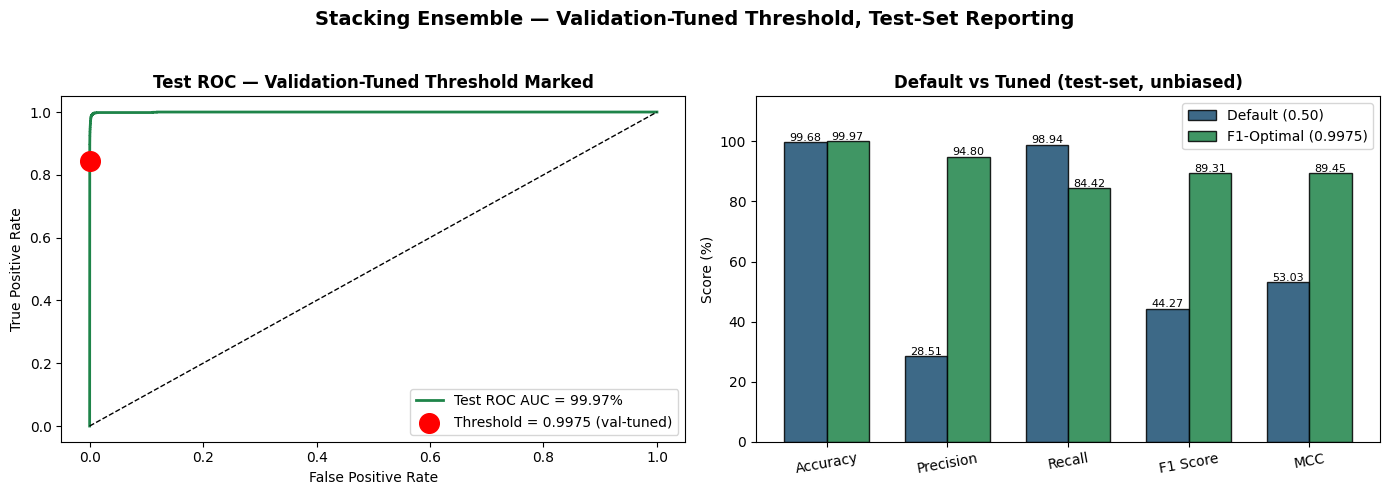


✅ Validation-tuned threshold 0.9975 stored for Gradio


In [17]:
# Cell 17 — F1-Optimal Threshold Tuned on VALIDATION (vectorized, fast)
# Process: Use precision_recall_curve (O(n log n)) instead of looping through
#          every threshold (which was O(n²) and took hours on 954K val).

from sklearn.metrics import precision_recall_curve

# Step 1 — Tune threshold on validation (vectorized)
y_val_prob              = ensemble.predict_proba(X_val_scaled)[:, 1]
prec_v, rec_v, thr_v    = precision_recall_curve(y_val, y_val_prob)
f1_v                    = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-10)
# precision_recall_curve returns one fewer threshold than precisions/recalls
optimal_idx             = int(np.argmax(f1_v[:-1]))
optimal_threshold       = round(float(thr_v[optimal_idx]), 4)

print(f"Default threshold     : 0.5000")
print(f"F1-optimal threshold  : {optimal_threshold}  (chosen on VALIDATION set)")
print(f"Val-set F1 at optimum : {f1_v[optimal_idx]*100:.2f}%\n")

# Step 2 — Apply chosen threshold to held-out TEST set
y_test_prob    = ensemble.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_test_prob >= 0.50).astype(int)
y_pred_optimal = (y_test_prob >= optimal_threshold).astype(int)

def thresh_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy'  : round(accuracy_score(y_true, y_pred)           * 100, 2),
        'Precision' : round(precision_score(y_true, y_pred)          * 100, 2),
        'Recall'    : round(recall_score(y_true, y_pred)             * 100, 2),
        'F1 Score'  : round(f1_score(y_true, y_pred)                 * 100, 2),
        'AUC-ROC'   : round(roc_auc_score(y_true, y_prob)            * 100, 2),
        'AUC-PR'    : round(average_precision_score(y_true, y_prob)  * 100, 2),
        'MCC'       : round(matthews_corrcoef(y_true, y_pred)        * 100, 2),
    }

default_m = thresh_metrics(y_test, y_pred_default, y_test_prob)
optimal_m = thresh_metrics(y_test, y_pred_optimal, y_test_prob)

print(f"{'Metric':<12} {'Default (0.50)':>16} "
      f"{'Optimal (' + str(optimal_threshold) + ')':>22}  {'Change':>8}")
print("=" * 68)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score',
               'AUC-ROC', 'AUC-PR', 'MCC']:
    d      = default_m[metric]
    o      = optimal_m[metric]
    change = round(o - d, 2)
    arrow  = "▲" if change > 0 else ("▼" if change < 0 else "─")
    print(f"{metric:<12} {d:>14.2f}%   {o:>16.2f}%       {arrow} {abs(change):.2f}%")
print("=" * 68)
print("\nThreshold chosen on VAL → reported on TEST → no optimistic bias.")
print("AUC-ROC and AUC-PR are threshold-independent.\n")

# Plot
fpr_t, tpr_t, thr_t = roc_curve(y_test, y_test_prob)
test_idx            = int(np.argmin(np.abs(thr_t - optimal_threshold)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_t, tpr_t, color='#1E8449', lw=2,
             label=f'Test ROC AUC = {default_m["AUC-ROC"]:.2f}%')
axes[0].scatter(fpr_t[test_idx], tpr_t[test_idx],
                color='red', s=200, zorder=5,
                label=f'Threshold = {optimal_threshold} (val-tuned)')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Test ROC — Validation-Tuned Threshold Marked', fontweight='bold')
axes[0].legend()

ml     = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MCC']
d_vals = [default_m[m] for m in ml]
o_vals = [optimal_m[m] for m in ml]
xi, wi = np.arange(len(ml)), 0.35
b1 = axes[1].bar(xi - wi/2, d_vals, wi, label='Default (0.50)',
                 color='#1B4F72', alpha=0.85, edgecolor='black')
b2 = axes[1].bar(xi + wi/2, o_vals, wi,
                 label=f'F1-Optimal ({optimal_threshold})',
                 color='#1E8449', alpha=0.85, edgecolor='black')
for bar, v in zip(b1, d_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5, f'{v:.2f}', ha='center', fontsize=8)
for bar, v in zip(b2, o_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5, f'{v:.2f}', ha='center', fontsize=8)
axes[1].set_xticks(xi); axes[1].set_xticklabels(ml, rotation=10)
axes[1].set_ylim(0, 115); axes[1].set_ylabel("Score (%)")
axes[1].set_title("Default vs Tuned (test-set, unbiased)", fontweight='bold')
axes[1].legend()
plt.suptitle("Stacking Ensemble — Validation-Tuned Threshold, Test-Set Reporting",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("optimal_threshold.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Validation-tuned threshold {optimal_threshold} stored for Gradio")

Generating SHAP analysis on the ENSEMBLE...


  0%|          | 0/100 [00:00<?, ?it/s]

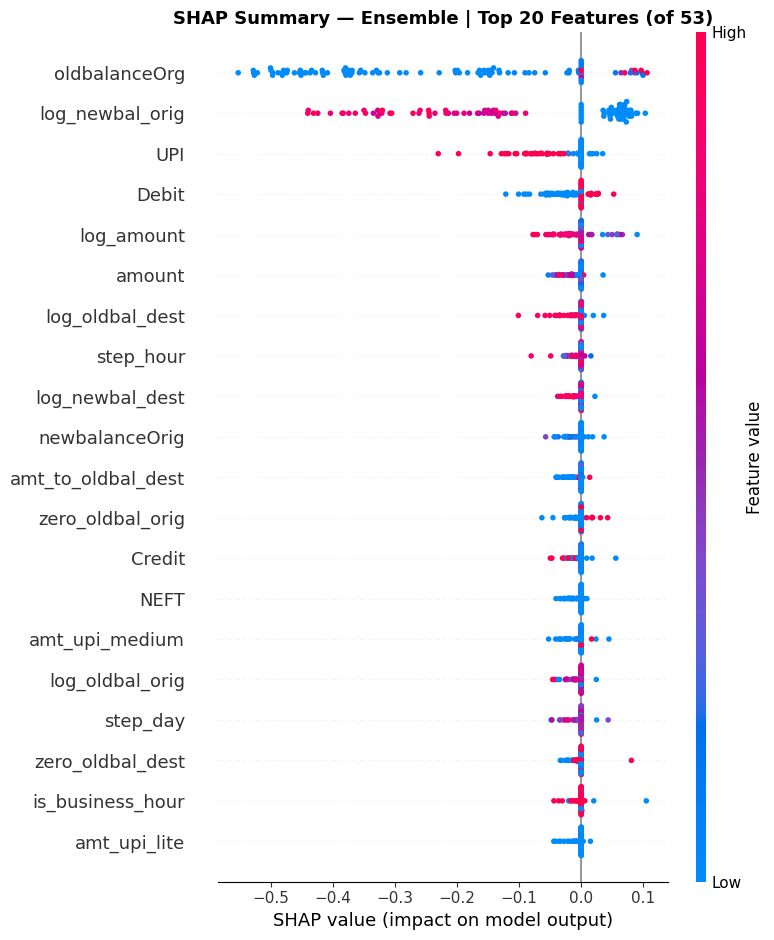

✅ SHAP on ensemble complete


In [18]:
# Cell 18 — SHAP on the actual ensemble
print("Generating SHAP analysis on the ENSEMBLE...")
try:
    np.random.seed(42)
    bg_idx = np.random.choice(len(X_train_res), size=100, replace=False)
    background = X_train_res[bg_idx]
    shap_explainer = shap.KernelExplainer(
        lambda x: ensemble.predict_proba(x)[:, 1],
        background
    )
    sample_idx  = np.random.choice(len(X_test_scaled),
                                   size=min(100, len(X_test_scaled)),
                                   replace=False)
    X_shap      = X_test_scaled[sample_idx]
    shap_values = shap_explainer.shap_values(X_shap, nsamples=100)
    plt.figure(figsize=(11, 7))
    shap.summary_plot(shap_values, X_shap,
                      feature_names=feature_names,
                      plot_type='dot', show=False, max_display=20)
    plt.title("SHAP Summary — Ensemble | Top 20 Features (of 53)",
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ SHAP on ensemble complete")
except Exception as e:
    print(f"⚠️ SHAP error: {e}")

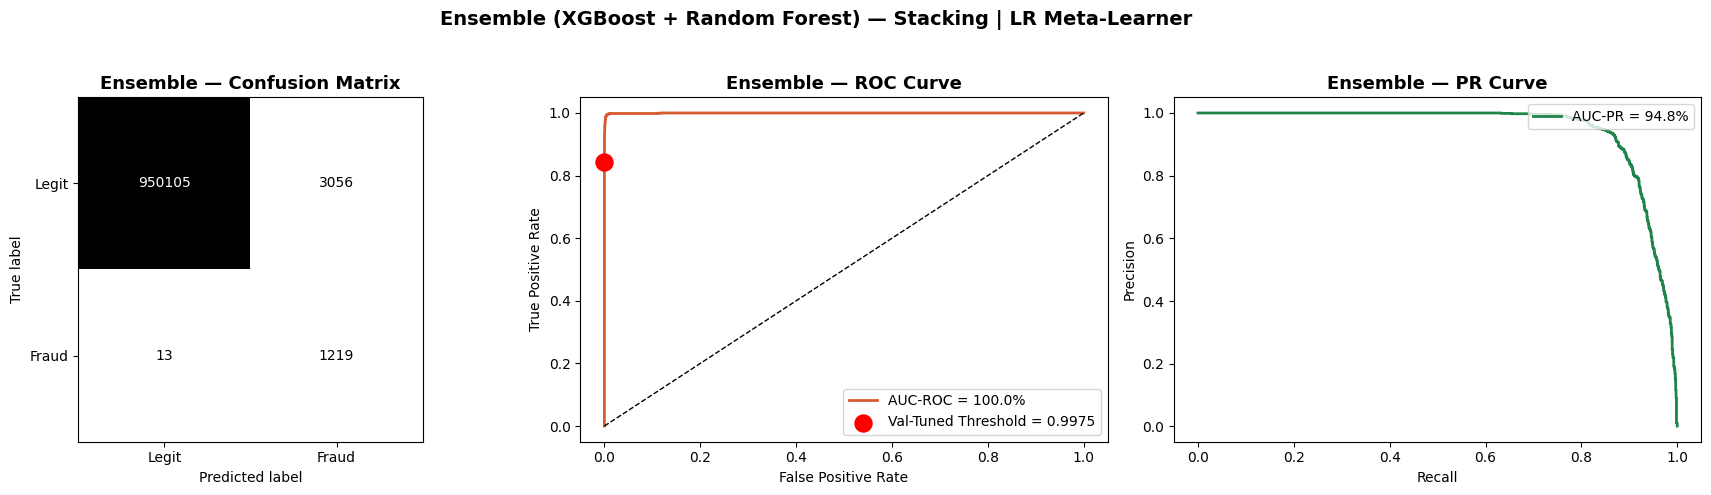

In [19]:
# Cell 19 — Ensemble Confusion Matrix + ROC + PR Curve
# Process: Confusion matrix, ROC curve, and PR curve for the stacking ensemble
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ens_pred = ensemble.predict(X_test_scaled)
ens_prob = ensemble.predict_proba(X_test_scaled)[:, 1]

cm   = confusion_matrix(y_test, ens_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legit', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greys')
axes[0].set_title('Ensemble — Confusion Matrix', fontsize=13, fontweight='bold')

fpr_e, tpr_e, thr_e = roc_curve(y_test, ens_prob)
opt_idx = np.argmin(np.abs(thr_e - optimal_threshold))
axes[1].plot(fpr_e, tpr_e, color='#D85A30', lw=2,
             label=f'AUC-ROC = {results["Ensemble (Best 2)"]["AUC-ROC"]:.1f}%')
axes[1].scatter(fpr_e[opt_idx], tpr_e[opt_idx],
                color='red', s=150, zorder=5,
                label=f'Val-Tuned Threshold = {optimal_threshold}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Ensemble — ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

prec_e, rec_e, _ = precision_recall_curve(y_test, ens_prob)
axes[2].plot(rec_e, prec_e, color='#1E8449', lw=2,
             label=f'AUC-PR = {results["Ensemble (Best 2)"]["AUC-PR"]:.1f}%')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Ensemble — PR Curve', fontsize=13, fontweight='bold')
axes[2].legend(loc='upper right')

ensemble_label = ' + '.join(best_2_names)
plt.suptitle(f"Ensemble ({ensemble_label}) — Stacking | LR Meta-Learner",
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("ensemble_eval.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Cell 20 — Save All Models
# Process: Persist all trained models, scaler, threshold, and feature schema to disk
joblib.dump(trained_models['Logistic Regression'], 'logistic_regression.pkl')
joblib.dump(trained_models['Decision Tree'],        'decision_tree.pkl')
joblib.dump(trained_models['Naive Bayes'],          'naive_bayes.pkl')
joblib.dump(trained_models['Random Forest'],        'random_forest.pkl')
joblib.dump(trained_models['XGBoost'],              'xgboost.pkl')
joblib.dump(ensemble,                               'ensemble.pkl')
joblib.dump(scaler,                                 'scaler.pkl')
joblib.dump(optimal_threshold,                      'optimal_threshold.pkl')
joblib.dump(feature_names,                          'feature_names.pkl')
print("✅ All models saved:")
print("   logistic_regression.pkl")
print("   decision_tree.pkl")
print("   naive_bayes.pkl")
print("   random_forest.pkl")
print("   xgboost.pkl")
print("   ensemble.pkl")
print("   scaler.pkl")
print(f"   optimal_threshold.pkl  ({optimal_threshold})")
print(f"   feature_names.pkl      ({len(feature_names)} features)")

✅ All models saved:
   logistic_regression.pkl
   decision_tree.pkl
   naive_bayes.pkl
   random_forest.pkl
   xgboost.pkl
   ensemble.pkl
   scaler.pkl
   optimal_threshold.pkl  (0.9975)
   feature_names.pkl      (38 features)


In [21]:
# Cell 21 — Gradio Interface
# Process: Interactive fraud detection UI with charts, SHAP explanation, val-tuned threshold
try:
    demo.close()
    print("Previous Gradio instance closed")
except:
    pass
import gradio as gr
pro_colors_full = ['#1B4F72', '#1A5276', '#6C3483', '#784212', '#922B21', '#1E8449']
pro_colors      = pro_colors_full[:-1]
print("Initializing SHAP...")
try:
    _explainer   = shap.TreeExplainer(trained_models['XGBoost'])
    SHAP_ENABLED = True
    print("✅ SHAP ready")
except Exception as e:
    SHAP_ENABLED = False
    print(f"⚠️ SHAP disabled: {e}")

# ── Helper: build the 37 engineered features from minimal user inputs ────────
# NOTE: Mirrors Cell 4 exactly — leaky features (balance errors, exact_balance_drain,
#       orig_balance_ratio, transfer_to_empty, etc.) are NOT built here.
def build_features(amount, transaction_type,
                   old_bal_sender, new_bal_sender,
                   old_bal_receiver, new_bal_receiver, step=1):
    type_flags = {
        'UPI (Payment)'        : dict(UPI=1,NEFT=0,RTGS=0,Credit=0,Debit=0,DirectDebit=0),
        'NEFT (Transfer ≤ 2L)' : dict(UPI=0,NEFT=1,RTGS=0,Credit=0,Debit=0,DirectDebit=0),
        'RTGS (Transfer > 2L)' : dict(UPI=0,NEFT=0,RTGS=1,Credit=0,Debit=0,DirectDebit=0),
        'Credit (Cash In)'     : dict(UPI=0,NEFT=0,RTGS=0,Credit=1,Debit=0,DirectDebit=0),
        'Debit (Cash Out)'     : dict(UPI=0,NEFT=0,RTGS=0,Credit=0,Debit=1,DirectDebit=0),
        'Auto Debit'           : dict(UPI=0,NEFT=0,RTGS=0,Credit=0,Debit=0,DirectDebit=1),
    }
    amt = float(amount)
    obo = float(old_bal_sender);   nbo = float(new_bal_sender)
    obd = float(old_bal_receiver); nbd = float(new_bal_receiver)
    eps = 1e-6

    # 1. Original transactional features
    f = {'step': step, 'amount': amt,
         'oldbalanceOrg': obo, 'newbalanceOrig': nbo,
         'oldbalanceDest': obd, 'newbalanceDest': nbd}

    # 2. Transaction-type flags
    f.update(type_flags[transaction_type])

    # 3. UPI / regional rail-aware amount bands
    f['amt_upi_lite']     = int(amt <= 500)
    f['amt_upi_micro']    = int(500 < amt <= 5000)
    f['amt_upi_small']    = int(5000 < amt <= 25000)
    f['amt_upi_medium']   = int(25000 < amt <= 100000)
    f['amt_upi_max_band'] = int(100000 < amt <= 200000)
    f['amt_rtgs_band']    = int(200000 < amt <= 1000000)
    f['amt_high_value']   = int(amt > 1000000)
    f['within_upi_cap']   = int(amt <= 100000)
    f['rtgs_eligible']    = int(amt >= 200000)

    # 4. Round-figure detectors
    f['amt_round_100']   = int(amt % 100   == 0)
    f['amt_round_1000']  = int(amt % 1000  == 0)
    f['amt_round_10000'] = int(amt % 10000 == 0)

    # 5. Logarithmic monetary features
    f['log_amount']      = np.log1p(amt)
    f['log_oldbal_orig'] = np.log1p(obo); f['log_newbal_orig'] = np.log1p(nbo)
    f['log_oldbal_dest'] = np.log1p(obd); f['log_newbal_dest'] = np.log1p(nbd)

    # 6. Ratio features (dest-side only — orig-side removed for de-leakage)
    f['amt_to_oldbal_dest'] = amt / (obd + eps)

    # 7. Anomaly indicators (zero_newbal_orig + amt_exceeds_balance REMOVED)
    f['zero_oldbal_orig'] = int(obo == 0)
    f['zero_oldbal_dest'] = int(obd == 0)
    f['zero_newbal_dest'] = int(nbd == 0)

    # 8. Temporal proxies
    f['step_hour']        = step % 24
    f['step_day']         = step // 24
    f['is_night_hour']    = int(0 <= (step % 24) < 6)
    f['is_business_hour'] = int(9 <= (step % 24) <= 18)

    # 9. Cross-feature interactions (transfer_to_empty + cashout_full_drain REMOVED)
    f['upi_high_amount']  = int(f['UPI'] == 1 and amt > 50000)

    return pd.DataFrame([f])[feature_names]

def show_chart(chart_type):
    if chart_type == "Classification metrics — bar chart":
        metrics_l = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        x, w      = np.arange(len(metrics_l)), 0.13
        fig, ax   = plt.subplots(figsize=(13, 6))
        fig.patch.set_facecolor('#F7F9FC'); ax.set_facecolor('#F7F9FC')
        for i, ((name, _, _), color) in enumerate(zip(model_list_full, pro_colors_full)):
            vals = [results[name][m] for m in metrics_l]
            bars = ax.bar(x + i*w, vals, w, label=name,
                          color=color, alpha=0.88, edgecolor='white', linewidth=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.4, f'{v:.2f}',
                        ha='center', fontsize=6, color='#2C3E50')
        ax.set_xticks(x + w*2.5); ax.set_xticklabels(metrics_l, fontsize=10)
        ax.set_ylim(0, 120); ax.set_ylabel("Score (%)", fontsize=11)
        ax.legend(fontsize=8, framealpha=0.9)
        ax.set_title("Classification Metrics — All Models + Ensemble",
                     fontsize=13, fontweight='bold', color='#1C2833')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    elif chart_type == "Ranking metrics — bar chart":
        metrics_l = ['AUC-ROC', 'AUC-PR', 'MCC']
        x, w      = np.arange(len(metrics_l)), 0.13
        fig, ax   = plt.subplots(figsize=(11, 6))
        fig.patch.set_facecolor('#F7F9FC'); ax.set_facecolor('#F7F9FC')
        for i, ((name, _, _), color) in enumerate(zip(model_list_full, pro_colors_full)):
            vals = [results[name][m] for m in metrics_l]
            bars = ax.bar(x + i*w, vals, w, label=name,
                          color=color, alpha=0.88, edgecolor='white', linewidth=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.4, f'{v:.2f}',
                        ha='center', fontsize=6, color='#2C3E50')
        ax.set_xticks(x + w*2.5); ax.set_xticklabels(metrics_l, fontsize=10)
        ax.set_ylim(0, 120); ax.set_ylabel("Score (%)", fontsize=11)
        ax.legend(fontsize=8, framealpha=0.9)
        ax.set_title("Ranking & Correlation Metrics — All Models + Ensemble",
                     fontsize=13, fontweight='bold', color='#1C2833')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    elif chart_type == "ROC curves":
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#F7F9FC'); ax.set_facecolor('#F7F9FC')
        for (name, model, _), color in zip(model_list_full[:-1], pro_colors):
            y_p         = model.predict_proba(X_test_scaled)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_p)
            ax.plot(fpr, tpr, color=color, lw=2,
                    label=f'{name}  AUC={results[name]["AUC-ROC"]:.2f}%')
        y_pe            = ensemble.predict_proba(X_test_scaled)[:, 1]
        fpr_e, tpr_e, _ = roc_curve(y_test, y_pe)
        ax.plot(fpr_e, tpr_e, color='#1E8449', lw=3, linestyle='--',
                label=f'Ensemble  AUC={results["Ensemble (Best 2)"]["AUC-ROC"]:.2f}%')
        ax.plot([0, 1], [0, 1], color='#AAB7B8', linestyle='--', lw=1)
        ax.set_xlabel('False Positive Rate', fontsize=11)
        ax.set_ylabel('True Positive Rate', fontsize=11)
        ax.set_title("ROC Curves — All Models + Ensemble",
                     fontsize=13, fontweight='bold', color='#1C2833')
        ax.legend(fontsize=9, framealpha=0.9)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(linestyle='--', alpha=0.3)
    elif chart_type == "Precision-Recall curves":
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.patch.set_facecolor('#F7F9FC'); ax.set_facecolor('#F7F9FC')
        for (name, model, _), color in zip(model_list_full[:-1], pro_colors):
            y_p          = model.predict_proba(X_test_scaled)[:, 1]
            prec, rec, _ = precision_recall_curve(y_test, y_p)
            ax.plot(rec, prec, color=color, lw=2,
                    label=f'{name}  AUC-PR={results[name]["AUC-PR"]:.2f}%')
        y_pe             = ensemble.predict_proba(X_test_scaled)[:, 1]
        prec_e, rec_e, _ = precision_recall_curve(y_test, y_pe)
        ax.plot(rec_e, prec_e, color='#1E8449', lw=3, linestyle='--',
                label=f'Ensemble  AUC-PR={results["Ensemble (Best 2)"]["AUC-PR"]:.2f}%')
        ax.set_xlabel('Recall', fontsize=11)
        ax.set_ylabel('Precision', fontsize=11)
        ax.set_title("Precision-Recall Curves — All Models + Ensemble",
                     fontsize=13, fontweight='bold', color='#1C2833')
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(linestyle='--', alpha=0.3)
    elif chart_type == "Confusion matrices":
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        fig.patch.set_facecolor('#F7F9FC'); axes = axes.flatten()
        cmaps = ['Blues', 'PuBu', 'Purples', 'YlOrBr', 'Reds', 'Greens']
        for idx, (name, model, _) in enumerate(model_list_full):
            axes[idx].set_facecolor('#F7F9FC')
            y_pred = model.predict(X_test_scaled)
            cm     = confusion_matrix(y_test, y_pred)
            disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                            display_labels=['Legit', 'Fraud'])
            disp.plot(ax=axes[idx], colorbar=False, cmap=cmaps[idx])
            axes[idx].set_title(name, fontsize=11, fontweight='bold', color='#1C2833')
        plt.suptitle("Confusion Matrices — All Models + Ensemble",
                     fontsize=14, fontweight='bold', color='#1C2833')
    elif chart_type in ("Accuracy comparison", "Precision comparison",
                        "Recall comparison", "F1 Score comparison",
                        "AUC-ROC comparison", "AUC-PR comparison",
                        "MCC comparison"):
        metric_key = chart_type.replace(" comparison", "")
        fig, ax    = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor('#F7F9FC'); ax.set_facecolor('#F7F9FC')
        vals = [results[n][metric_key] for n in all_names_full]
        bars = ax.bar(all_names_full, vals, color=pro_colors_full,
                      alpha=0.88, edgecolor='white', linewidth=0.5)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.5, f'{v:.2f}%',
                    ha='center', fontsize=10, color='#2C3E50', fontweight='bold')
        ax.set_ylim(0, 115); ax.set_ylabel(f"{metric_key} (%)", fontsize=11)
        ax.set_title(f"{metric_key} — All Models + Ensemble",
                     fontsize=13, fontweight='bold', color='#1C2833')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        plt.xticks(rotation=15, ha='right', fontsize=9)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img = Image.open(buf).copy()
    plt.close()
    return img

def predict_fraud(amount, transaction_type,
                  old_bal_sender, new_bal_sender,
                  old_bal_receiver, new_bal_receiver):
    input_df = build_features(amount, transaction_type,
                              old_bal_sender, new_bal_sender,
                              old_bal_receiver, new_bal_receiver)
    scaled  = scaler.transform(input_df)
    probs   = ensemble.predict_proba(scaled)[0]
    fraud_p = round(probs[1] * 100, 2)
    legit_p = round(probs[0] * 100, 2)
    pred    = 1 if probs[1] >= optimal_threshold else 0
    if pred == 1:
        result_text = (f"🚨  FRAUDULENT TRANSACTION DETECTED\n\n"
                       f"Fraud Probability  : {fraud_p:.2f}%\n"
                       f"Legit Probability  : {legit_p:.2f}%\n\n"
                       f"Threshold Used     : {optimal_threshold} (val-tuned, F1-optimal)")
    else:
        result_text = (f"✅  LEGITIMATE TRANSACTION\n\n"
                       f"Fraud Probability  : {fraud_p:.2f}%\n"
                       f"Legit Probability  : {legit_p:.2f}%\n\n"
                       f"Threshold Used     : {optimal_threshold} (val-tuned, F1-optimal)")
    shap_img = None
    if SHAP_ENABLED:
        try:
            shap_vals = _explainer.shap_values(scaled)
            fig, ax   = plt.subplots(figsize=(11, 5))
            fig.patch.set_facecolor('#F7F9FC')
            shap.waterfall_plot(
                shap.Explanation(
                    values        = shap_vals[0],
                    base_values   = _explainer.expected_value,
                    data          = input_df.values[0],
                    feature_names = feature_names
                ), max_display=12, show=False)
            plt.title("Why this decision? (SHAP — XGBoost, top 12 features)",
                      fontsize=12, fontweight='bold', color='#1C2833')
            plt.tight_layout()
            buf = io.BytesIO()
            plt.savefig(buf, format='png', dpi=130, bbox_inches='tight',
                        facecolor='#F7F9FC')
            buf.seek(0)
            shap_img = Image.open(buf).copy()
            plt.close()
        except Exception as e:
            print(f"SHAP error: {e}")
    return result_text, shap_img

with gr.Blocks(
    title="Financial Fraud Detection",
    theme=gr.themes.Soft(
        primary_hue="slate",
        secondary_hue="blue",
        neutral_hue="slate",
        font=gr.themes.GoogleFont("Inter")
    ),
    css="""
        .gradio-container { max-width: 1200px; margin: auto; }
        .gr-button-primary { background: #1B4F72 !important; border: none !important; }
        footer { display: none !important; }
    """
) as demo:
    gr.Markdown(f"""
    # 🏦 Financial Fraud Detection System
    **Ensemble: {' + '.join(best_2_names)} → Stacking (LR Meta-Learner) | PaySim Dataset**
    **{len(feature_names)} engineered features (UPI/NEFT/RTGS domain-adapted) | val-tuned threshold = {optimal_threshold}**
    """)
    with gr.Tabs():
        with gr.TabItem("🔍 Fraud Detection"):
            gr.Markdown("### Enter Transaction Details")
            with gr.Row():
                with gr.Column():
                    gr.Markdown("**💳 Transaction Info**")
                    amount_input = gr.Number(label="Amount (₹)", value=10000, minimum=1)
                    txn_type     = gr.Dropdown(
                        choices=['UPI (Payment)', 'NEFT (Transfer ≤ 2L)',
                                 'RTGS (Transfer > 2L)', 'Credit (Cash In)',
                                 'Debit (Cash Out)', 'Auto Debit'],
                        label="Transaction Type", value='UPI (Payment)')
                with gr.Column():
                    gr.Markdown("**👤 Sender Balances**")
                    old_bal_sender = gr.Number(label="Sender Balance Before (₹)", value=50000)
                    new_bal_sender = gr.Number(label="Sender Balance After (₹)",  value=40000)
                with gr.Column():
                    gr.Markdown("**👥 Receiver Balances**")
                    old_bal_receiver = gr.Number(label="Receiver Balance Before (₹)", value=0)
                    new_bal_receiver = gr.Number(label="Receiver Balance After (₹)",  value=0)
            predict_btn = gr.Button("🔍 Analyse Transaction", variant="primary", size="lg")
            with gr.Row():
                output_text = gr.Textbox(label="Ensemble Prediction Result",
                                         lines=6, show_copy_button=True)
                shap_output = gr.Image(label="Why this decision? (SHAP Explanation)",
                                       type="pil")
            predict_btn.click(
                fn=predict_fraud,
                inputs=[amount_input, txn_type,
                        old_bal_sender, new_bal_sender,
                        old_bal_receiver, new_bal_receiver],
                outputs=[output_text, shap_output])
        with gr.TabItem("📊 Model Performance"):
            gr.Markdown("### Compare All Models + Ensemble")
            chart_dd = gr.Dropdown(
                choices=["Classification metrics — bar chart",
                         "Ranking metrics — bar chart",
                         "ROC curves",
                         "Precision-Recall curves",
                         "Confusion matrices",
                         "Accuracy comparison",
                         "Precision comparison",
                         "Recall comparison",
                         "F1 Score comparison",
                         "AUC-ROC comparison",
                         "AUC-PR comparison",
                         "MCC comparison"],
                label="Select Chart Type",
                value="Classification metrics — bar chart")
            chart_out = gr.Image(label="Performance Chart", type="pil")
            chart_dd.change(fn=show_chart, inputs=chart_dd, outputs=chart_out)
            demo.load(fn=show_chart,  inputs=chart_dd, outputs=chart_out)
demo.launch(share=True)

Initializing SHAP...
✅ SHAP ready
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f56d6828c7a8c4cef3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
